## Similarity task

In [1]:
model_name = 'intern3' #'qwen', 'intern' or 'gemma'
run_all = True # if false, runs just on the first few images, then plots results using
                # pre-computed data

#### Import and utilities

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from ast import literal_eval # to get dict/list from csv
import hydra
import os
import matplotlib.pyplot as plt
from scipy import stats
from transformers.utils import ModelOutput
from transformers import GenerationConfig
import string
from tqdm import tqdm

import pyrootutils,sys
pyrootutils.setup_root('.',cwd=True,pythonpath=False)
sys.path.append('./src')

from vlm_datasets.similarity import all_colors,all_letters, make_image_multi, make_image_query

In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       intern3='+experiment=bal_internvl3_8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  ])

/tmp/ipykernel_3621169/2378118459.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [ ]:
## Functions to format inputs and generate outputs (model-dependent)

from qwen_vl_utils import process_vision_info
def get_qwen_inputs_2imgs(model,processor,img_path1,img_path2,query_string):
    batch_messages = [[{'role': 'system', 'content': 'You are a helpful assistant.'}, 
      {'role': 'user', 'content': [{'type': 'image', 'image': img_path1}, 
                                   {'type': 'image', 'image': img_path2}, 
        {'type': 'text', 'text': query_string}]}]]
    texts = [
            processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=True
            ) for msg in batch_messages
        ]
    image_inputs, video_inputs = process_vision_info(batch_messages)
    inputs = processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors='pt'
        ).to(model.device)
    return inputs

def get_intvl_inputs_2imgs(model,processor,img_path1,img_path2,query_string):
    messages = [{"role": "system","content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user","content": [{"type": "image", "image": img_path1},{"type": "image", "image": img_path2},
                                {"type": "text", "text": query_string}]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device, dtype=torch.bfloat16)
    return inputs

def get_gemma_inputs_2imgs(model,processor,img_path1,img_path2,query_string):
    messages = [{"role": "system","content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user","content": [{"type": "image", "image": img_path1},{"type": "image", "image": img_path2},
                                {"type": "text", "text": query_string}]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device, dtype=torch.bfloat16)
    return inputs

#####
def ask_qwen_2imgs(model,processor,vocab,img_path1,img_path2,query):
    inputs = get_qwen_inputs_2imgs(model,processor,img_path1,img_path2,query)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=128,
                return_dict_in_generate=True, output_scores=True, output_logits=True)
    num_system_tokens = 14
    num_image_tokens = 326  # 18 x 18 + 2 (start, end image token)
    num_user_tokens = inputs.input_ids.shape[1] - num_system_tokens - num_image_tokens
    str_out = processor.decode(output.sequences[0][num_system_tokens+num_image_tokens+num_user_tokens:-1])
    logits = output['logits'][0][0]
    return {'Q':query,'A':str_out,'logits':logits}

def ask_intvl_2imgs(model,processor,vocab,img_path1,img_path2,query):
    inputs = get_intvl_inputs_2imgs(model,processor,img_path1,img_path2,query)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=100, do_sample=False,
            output_logits=True,
            top_p=1.0, top_k=50, # these to avoid a warning message for every call..
            return_dict_in_generate=True, output_scores=True,
            pad_token_id=151645) #specific for internvl 3.5 8B
    str_out = processor.decode(generation['sequences'][0][input_len:-1])
    logits = generation['logits'][0][0]
    return {'Q':query,'A':str_out,'logits':logits,'raw':generation}

def ask_gemma_2imgs(model,processor,vocab,img_path1,img_path2,query):
    inputs = get_gemma_inputs_2imgs(model,processor,img_path1,img_path2,query)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=100, do_sample=False,
            output_logits=True,
            top_p=1.0, top_k=50, # these to avoid a warning message for every call..
            return_dict_in_generate=True, output_scores=True)
    str_out = processor.decode(generation['sequences'][0][input_len:-1])
    logits = generation['logits'][0][0]
    return {'Q':query,'A':str_out,'logits':logits,}

###

def find_value_qwen(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['Ġ'+x for x in candidates] + ['ġ'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

def find_value_intvl(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['▁'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

def find_value_gemma(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['▁'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found


##########

if model_name == 'qwen':
  get_inputs_2img = get_qwen_inputs_2imgs
  ask_2imgs = ask_qwen_2imgs
  find_value = find_value_qwen
elif model_name == 'intern3':
  get_inputs_2img = get_intvl_inputs_2imgs
  ask_2imgs = ask_intvl_2imgs
  find_value = find_value_intvl
elif model_name == 'gemma':
  get_inputs_2img = get_gemma_inputs_2imgs
  ask_2imgs = ask_gemma_2imgs
  find_value = find_value_gemma
else:
  raise KeyError

### Load concept vector and hue similarities

In [5]:
def compute_hue_similarity(idx1, idx2):
    if idx1 == -1 or idx2 == -1:
        return 0.0

    #all_colors = np.linspace(0, 360, num=101)[:-1]
    h1 = all_colors[idx1]
    h2 = all_colors[idx2]

    dist = min(abs(h1 - h2), 360 - abs(h1 - h2))
    return 1 - (dist / 180)

hue_sim = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        hue_sim[i,j]=compute_hue_similarity(i,j)

In [6]:
def simmatrix(V):
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return sims

cv = torch.load(os.path.join('outputs','semanticity',cfg.model.model_name+'_nsq_cv.pt'))
cv_sim = simmatrix(cv)

In [7]:
def similarity(h1, h2, source):
    if h1==-1 or h2==-1:
        return -1.
    match source:                                                   
      case 'cv':                                             
          return cv_sim[h1][h2].item()
      case 'hue':                                               
          return hue_sim[h1][h2]                    
      case _:                                                   
          raise ValueError(f"Unknown matrix: {source}")

#### Generate/load dataset

In [8]:
DATASET_PATH = './data/similarity_dataset/'

# Reference images (A B C...)
COLOR_REFERENCE_DATASET = DATASET_PATH + 'img_ref/'

# Query images (single square)
COLOR_SIMILARITY_DATASET = DATASET_PATH + 'img_que/'

os.makedirs(COLOR_REFERENCE_DATASET,exist_ok=True)
os.makedirs(COLOR_SIMILARITY_DATASET,exist_ok=True)

In [9]:
# Create column names dynamically
first_12 = string.ascii_uppercase[:12]
hue_columns = ['HUE_INDEX_'+k for k in first_12]
dtype_dict = {col: pd.Int64Dtype() for col in hue_columns}
dtype_dict['ID'] = 'str'
columns = ['ID','N_STENCILS']+hue_columns
stencil_values = [4,6,8,10,12]
num_exp = 1000
nrows = len(stencil_values)*num_exp

In [10]:
## Generate metadata only if not already present
meta_path = DATASET_PATH+"metainfo_sim.csv"
if os.path.exists(meta_path):
    print('Loading metadata')
    metainfo_sim = pd.read_csv(meta_path,dtype=dict(ID=str))
else:
    print('Generating dataset metadata')
    metadata = pd.DataFrame(-1, index=range(nrows), columns=columns)
    for i,row in metadata.iterrows():
        metadata.loc[i,'ID'] = str(i).zfill(4)
        n_stencils = stencil_values[i//num_exp]
        metadata.loc[i,'N_STENCILS'] = n_stencils
        random_colors = np.random.randint(100,size=n_stencils)
        for ci,ce in enumerate(random_colors):
            metadata.loc[i,'HUE_INDEX_'+first_12[ci]] = ce
    metainfo_sim = metadata.copy()
    metainfo_sim['TARGET_HUE_INDEX']=-1
    metainfo_sim['correct_answer']=''
    for k in first_12:
        metainfo_sim['HUE_INDEX_'+k+'_sim']=0.
    for i,row in metainfo_sim.iterrows():
        col_index = np.random.randint(100)#updated
        metainfo_sim.loc[i,'TARGET_HUE_INDEX'] = col_index
        n_stencils = int(row['N_STENCILS'])
        for k in first_12[:n_stencils]:
            metainfo_sim.loc[i,'HUE_INDEX_'+k+'_sim']=similarity(metainfo_sim.loc[i,'HUE_INDEX_'+k], col_index,'hue')
        metainfo_sim.loc[i,'correct_answer'] = sorted(
            [(k,metainfo_sim.loc[i,'HUE_INDEX_'+k+'_sim']) for k in first_12[:n_stencils]],
            key=lambda x:x[1]
            )[-1][0]
    metainfo_sim.to_csv(meta_path,index=False)

Loading metadata


100%|██████████| 5000/5000 [00:38<00:00, 131.27it/s]


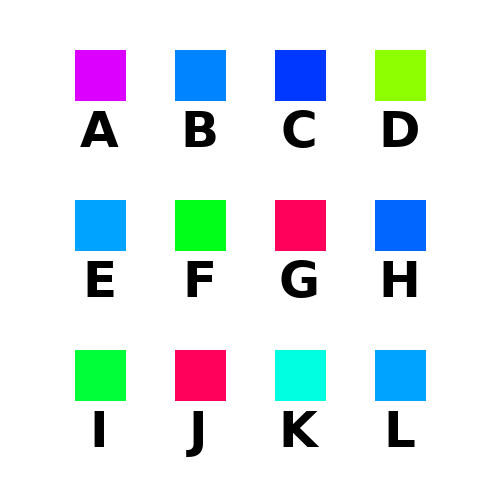

In [11]:
# Save reference images
stopindex = metainfo_sim.shape[0] if run_all else 3 #GUARD
for i in tqdm(range(stopindex)):
    n_stencils = metainfo_sim.loc[i,'N_STENCILS']
    cols_indexes = metainfo_sim.iloc[i][hue_columns[:n_stencils]].values
    canvas = make_image_multi(n_stencils,cols_indexes)
    canvas.save(COLOR_REFERENCE_DATASET+str(metainfo_sim.iloc[i]['ID']).zfill(4)+'.png')
canvas.show()

100%|██████████| 5000/5000 [00:25<00:00, 196.81it/s]


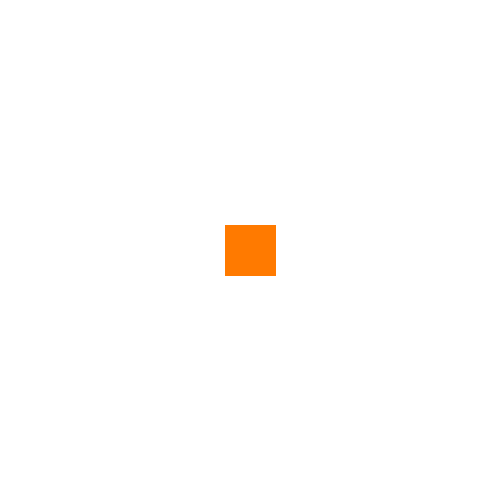

In [12]:
# Save query images
for i in tqdm(range(stopindex)):
    col = metainfo_sim.loc[i,'TARGET_HUE_INDEX']
    # print(col)
    canvas = make_image_query(col)
    fname = str(metainfo_sim.iloc[i]['ID']).zfill(4)+'.png'
    canvas.save(COLOR_SIMILARITY_DATASET+fname)
canvas.show()

### Collect VLM answers

In [13]:
model = hydra.utils.instantiate(cfg.model)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [23]:
metainfo_sim['model_answer']=None
for s in all_letters:
    metainfo_sim[s]=None

In [24]:
def make_query(n):
    q = 'In the first picture there are '+str(n)+' squares of different colors, labelled with uppercase letters: '
    q += 'A B C D E F G H I J K L '[:(n*2)][:-1]
    q += '.\nIn the second picture there is only one target square.\n'+\
    'Identify which square in the first picture is most similar to the target square in the second picture.\n'+\
    'Reply with the corresponding letter and nothing else.'
    return q

In [25]:
for i, row in tqdm(metainfo_sim.iterrows()):
    if (not run_all) and i==3:#20:#GUARD
       break#remove this guard to run over all images
    # if i%100==0:
    #     print(i,end=' ')
    img_path_1 = COLOR_REFERENCE_DATASET+str(row['ID']).zfill(4)+'.png'
    img_path_2 = COLOR_SIMILARITY_DATASET+str(row['ID']).zfill(4)+'.png'
    query = make_query(int(row['N_STENCILS']))
    response = ask_2imgs(model.model,model.processor,model.vocab,img_path_1,img_path_2,query)
    
    answer = response['A'].upper().strip()
    if len(answer.split()) > 1 or answer not in all_letters:
        print('UNEXPECTED ANSWER '+str(row['ID'])+'--------->'+answer)
    metainfo_sim.loc[i,'model_answer']=answer
    for s in all_letters:
        metainfo_sim.loc[i,s]=response['logits'][find_value_intvl(model.vocab,s)].item()

5000it [11:58,  6.96it/s]


In [26]:
# Enrich metadata with concept vector similarities
for k in all_letters[:12]:
    metainfo_sim['TEMPLATE_'+k+'_sim'] = metainfo_sim.apply(lambda x : \
                            similarity(x['HUE_INDEX_'+k], x['TARGET_HUE_INDEX'], 'cv'),axis=1)

In [27]:
if run_all:
  metainfo_sim.to_csv(f'./outputs/similarity_task/{model_name}_results_sim.csv')
  print('data saved')
else:
  print('skip saving data')

data saved


### Correlations and scatterplots

In [28]:
model_name # can be set to "qwen", "intern" or "gemma"

'intern3'

In [29]:
# Configuration
DATA_FILE = f'./outputs/similarity_task/{model_name}_results_sim.csv'#intvl_results_sim
Y_COLUMN = '(token) logit separation'  # Options: 'TOKEN_DIFF', 'MAX_TOKEN', or any column name

In [30]:
# Load data
df = pd.read_csv(DATA_FILE)
print(f'Loaded {len(df)} rows from {DATA_FILE}')

Loaded 5000 rows from ./outputs/similarity_task/intern3_results_sim.csv


In [31]:
# Compute derived columns
token_cols = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
options = list('ABCDEFGHIJKL')

def get_winning_letter(row):
    vals = {c: row[c] for c in token_cols}
    return max(vals, key=vals.get)

def get_token_diff(row):
    winner = row['winning_letter']
    n_stencils = int(row['N_STENCILS'])
    active = options[:n_stencils]
    winner_val = row[winner]
    other_vals = [row[c] for c in active if c != winner]
    if len(other_vals) == 0:
        return np.nan
    return winner_val - np.mean(other_vals)

def get_max_token(row):
    return max(row[c] for c in token_cols)

def winner_has_best_hue(row):
    winner = row['model_answer']
    if pd.isna(winner) or winner not in options:
        return False
    n_stencils = int(row['N_STENCILS'])
    active = options[:n_stencils]
    winner_val = row[f'HUE_INDEX_{winner}_sim']
    for c in active:
        if c != winner and row[f'HUE_INDEX_{c}_sim'] > winner_val:
            return False
    return True

def winner_has_best_template(row):
    winner = row['model_answer']
    if pd.isna(winner) or winner not in options:
        return False
    n_stencils = int(row['N_STENCILS'])
    active = options[:n_stencils]
    winner_val = row[f'TEMPLATE_{winner}_sim']
    for c in active:
        if c != winner and row[f'TEMPLATE_{c}_sim'] > winner_val:
            return False
    return True

df['winning_letter'] = df.apply(get_winning_letter, axis=1)
df['(token) logit separation'] = df.apply(get_token_diff, axis=1)
df['MAX_TOKEN'] = df.apply(get_max_token, axis=1)
df['best_hue'] = df.apply(winner_has_best_hue, axis=1)
df['best_template'] = df.apply(winner_has_best_template, axis=1)

print('Computed: TOKEN_SEP, MAX_TOKEN, best_hue, best_template')

Computed: TOKEN_SEP, MAX_TOKEN, best_hue, best_template


In [32]:
hue_options = [f'HUE_INDEX_{letter}_sim' for letter in 'ABCDEFGHIJKL']

def hue_sep(row):
    winner = row['winning_letter']
    n_stencils = int(row['N_STENCILS'])
    active = hue_options[:n_stencils]
    if not winner in options[:n_stencils]:
        return np.nan
    winner_val = row[f'HUE_INDEX_{winner}_sim']

    other_vals = [row[c] for c in active if c != winner]
    # if len(other_vals) == 0:
    #     return np.nan
    return winner_val - np.mean(other_vals)
df['HUE_SEP'] = df.apply(hue_sep, axis=1)


In [33]:
template_options = [f'TEMPLATE_{letter}_sim' for letter in 'ABCDEFGHIJKL']

def template_sep(row):
    winner = row['winning_letter']
    n_stencils = int(row['N_STENCILS'])
    active = template_options[:n_stencils]
    if not winner in options[:n_stencils]:
        return np.nan

    winner_val = row[f'TEMPLATE_{winner}_sim']
    
    other_vals = [row[c] for c in active if c != winner]
    # if len(other_vals) == 0:
    #     return np.nan
    return winner_val - np.mean(other_vals)

df['TEMPLATE_SEP'] = df.apply(template_sep, axis=1)

In [34]:
template_options[:6]

['TEMPLATE_A_sim',
 'TEMPLATE_B_sim',
 'TEMPLATE_C_sim',
 'TEMPLATE_D_sim',
 'TEMPLATE_E_sim',
 'TEMPLATE_F_sim']

In [35]:
df.keys()

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ID', 'N_STENCILS', 'HUE_INDEX_A',
       'HUE_INDEX_B', 'HUE_INDEX_C', 'HUE_INDEX_D', 'HUE_INDEX_E',
       'HUE_INDEX_F', 'HUE_INDEX_G', 'HUE_INDEX_H', 'HUE_INDEX_I',
       'HUE_INDEX_J', 'HUE_INDEX_K', 'HUE_INDEX_L', 'TARGET_HUE_INDEX',
       'correct_answer', 'HUE_INDEX_A_sim', 'HUE_INDEX_B_sim',
       'HUE_INDEX_C_sim', 'HUE_INDEX_D_sim', 'HUE_INDEX_E_sim',
       'HUE_INDEX_F_sim', 'HUE_INDEX_G_sim', 'HUE_INDEX_H_sim',
       'HUE_INDEX_I_sim', 'HUE_INDEX_J_sim', 'HUE_INDEX_K_sim',
       'HUE_INDEX_L_sim', 'model_answer', 'A', 'B', 'C', 'D', 'E', 'F', 'G',
       'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U',
       'V', 'W', 'X', 'Y', 'Z', 'TEMPLATE_A_sim', 'TEMPLATE_B_sim',
       'TEMPLATE_C_sim', 'TEMPLATE_D_sim', 'TEMPLATE_E_sim', 'TEMPLATE_F_sim',
       'TEMPLATE_G_sim', 'TEMPLATE_H_sim', 'TEMPLATE_I_sim', 'TEMPLATE_J_sim',
       'TEMPLATE_K_sim', 'TEMPLATE_L_sim', 'winning_letter',
       '(token) logit sepa

In [36]:
# Filter valid rows
df_valid = df.dropna(subset=['HUE_SEP', 'TEMPLATE_SEP', Y_COLUMN])
print(f'Valid rows: {len(df_valid)} / {len(df)}')
# Calculate correlations
corr_hue = df_valid['HUE_SEP'].corr(df_valid[Y_COLUMN])
corr_template = df_valid['TEMPLATE_SEP'].corr(df_valid[Y_COLUMN])
pct_best_hue = df_valid['best_hue'].mean() * 100
pct_best_template = df_valid['best_template'].mean() * 100

print(f'Correlation HUE_SEP vs {Y_COLUMN}: {corr_hue:.4f}')
print(f'Correlation TEMPLATE_SEP vs {Y_COLUMN}: {corr_template:.4f}')
print(f'Winner has best HUE: {pct_best_hue:.1f}%')
print(f'Winner has best TEMPLATE: {pct_best_template:.1f}%')

Valid rows: 5000 / 5000
Correlation HUE_SEP vs (token) logit separation: 0.6305
Correlation TEMPLATE_SEP vs (token) logit separation: 0.7542
Winner has best HUE: 69.5%
Winner has best TEMPLATE: 70.1%


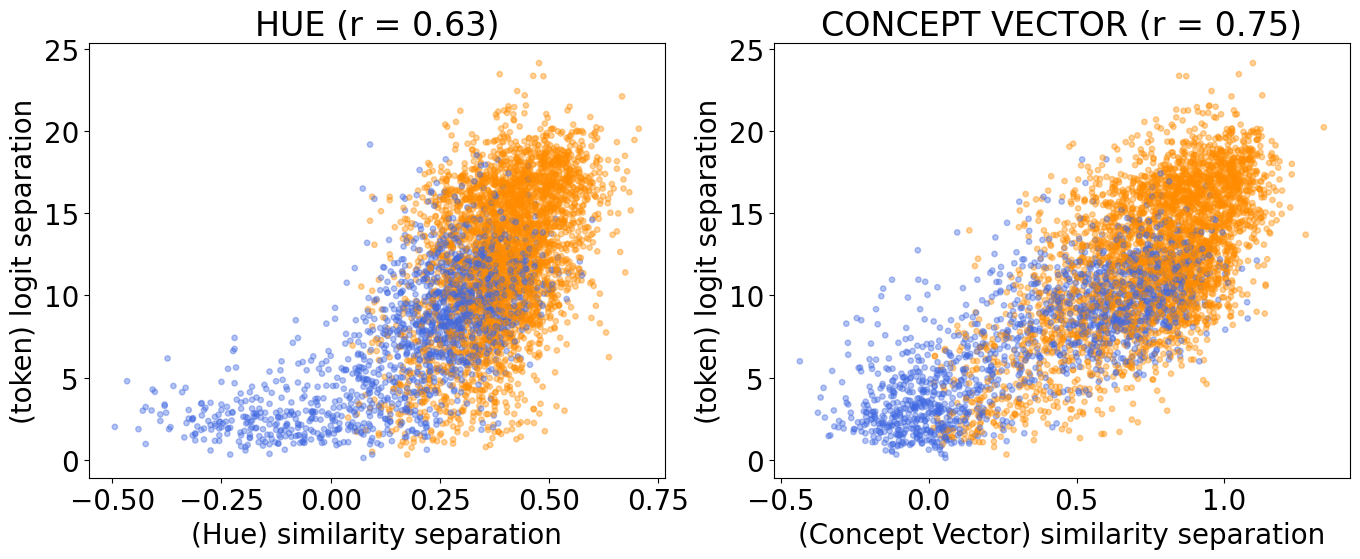

In [37]:
# Plot scatterplots
fs = 20
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_hue = ['darkorange' if b else 'royalblue' for b in df_valid['best_hue']]
colors_template = ['darkorange' if b else 'royalblue' for b in df_valid['best_template']]

# HUE_SEP panel
axes[0].scatter(df_valid['HUE_SEP'], df_valid[Y_COLUMN], c=colors_hue, alpha=0.4, s=15)
axes[0].set_xlabel('(Hue) similarity separation', fontsize=fs)
axes[0].set_ylabel(Y_COLUMN, fontsize=fs)
axes[0].set_title(f'HUE (r = {corr_hue:.2f})')
axes[0].tick_params(labelsize=fs)

# TEMPLATE_SEP panel
axes[1].scatter(df_valid['TEMPLATE_SEP'], df_valid[Y_COLUMN], c=colors_template, alpha=0.4, s=15)
axes[1].set_xlabel('(Concept Vector) similarity separation', fontsize=fs)
axes[1].set_ylabel(Y_COLUMN, fontsize=fs)
axes[1].set_title(f'CONCEPT VECTOR (r = {corr_template:.2f})')
axes[1].tick_params(labelsize=fs)

plt.tight_layout()
plt.savefig(f'./outputs/similarity_task/{model_name}_results_sim_colorblind.pdf', dpi=150)
plt.show()